# 1.准备工作

In [ ]:
!pip install ultralytics==8.3.226
!pip install -q ultralytics grad-cam ttach opencv-python pillow torchvision
!git clone -q https://github.com/rigvedrs/YOLO-V8-CAM.git

In [ ]:
# Import
import os
import cv2
import shutil
import torch
import torch.nn as nn
import ultralytics
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image
from ultralytics import RTDETR
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
RANDOM_STATE = 10086

In [ ]:
# Verify GPU availability (should be A100 on Colab)
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


CUDA Available: True
GPU Device: NVIDIA GeForce RTX 3070 Ti Laptop GPU
GPU Memory: 8.59 GB


# 读取数据

In [ ]:
import kagglehub
from pathlib import Path
import yaml

data_path = kagglehub.dataset_download("rupankarmajumdar/crop-pests-dataset")
print(f"Data downloaded to: {data_path}")
data_path = Path(data_path)

with open(data_path / 'data.yaml', 'r') as file:
    yaml_config = yaml.safe_load(file)

class_names = yaml_config['names']

print("\nClass Names:")
for i, class_name in enumerate(class_names, 1):  # 从1开始编号
    print(f"    {i}. {class_name}")

train_img_path = data_path / 'train' / 'images'
train_lab_path = data_path / 'train' / 'labels'

test_img_path = data_path / 'test' / 'images'
test_lab_path = data_path / 'test' / 'labels'

valid_img_path = data_path / 'valid' / 'images'
valid_lab_path = data_path / 'valid' / 'labels'

print(f"\nTrain image number: {len(list(train_img_path.glob('*.jpg')))}")
print(f"Test image number: {len(list(test_img_path.glob('*.jpg')))}")
print(f"Valid image number: {len(list(valid_img_path.glob('*.jpg')))}")

Data downloaded to: C:\Users\12235\.cache\kagglehub\datasets\rupankarmajumdar\crop-pests-dataset\versions\2

Class Names:
    1. Ants
    2. Bees
    3. Beetles
    4. Caterpillars
    5. Earthworms
    6. Earwigs
    7. Grasshoppers
    8. Moths
    9. Slugs
    10. Snails
    11. Wasps
    12. Weevils

Train image number: 11502
Test image number: 546
Valid image number: 1095


# 分析数据分布

========= Training Set Distribution =========


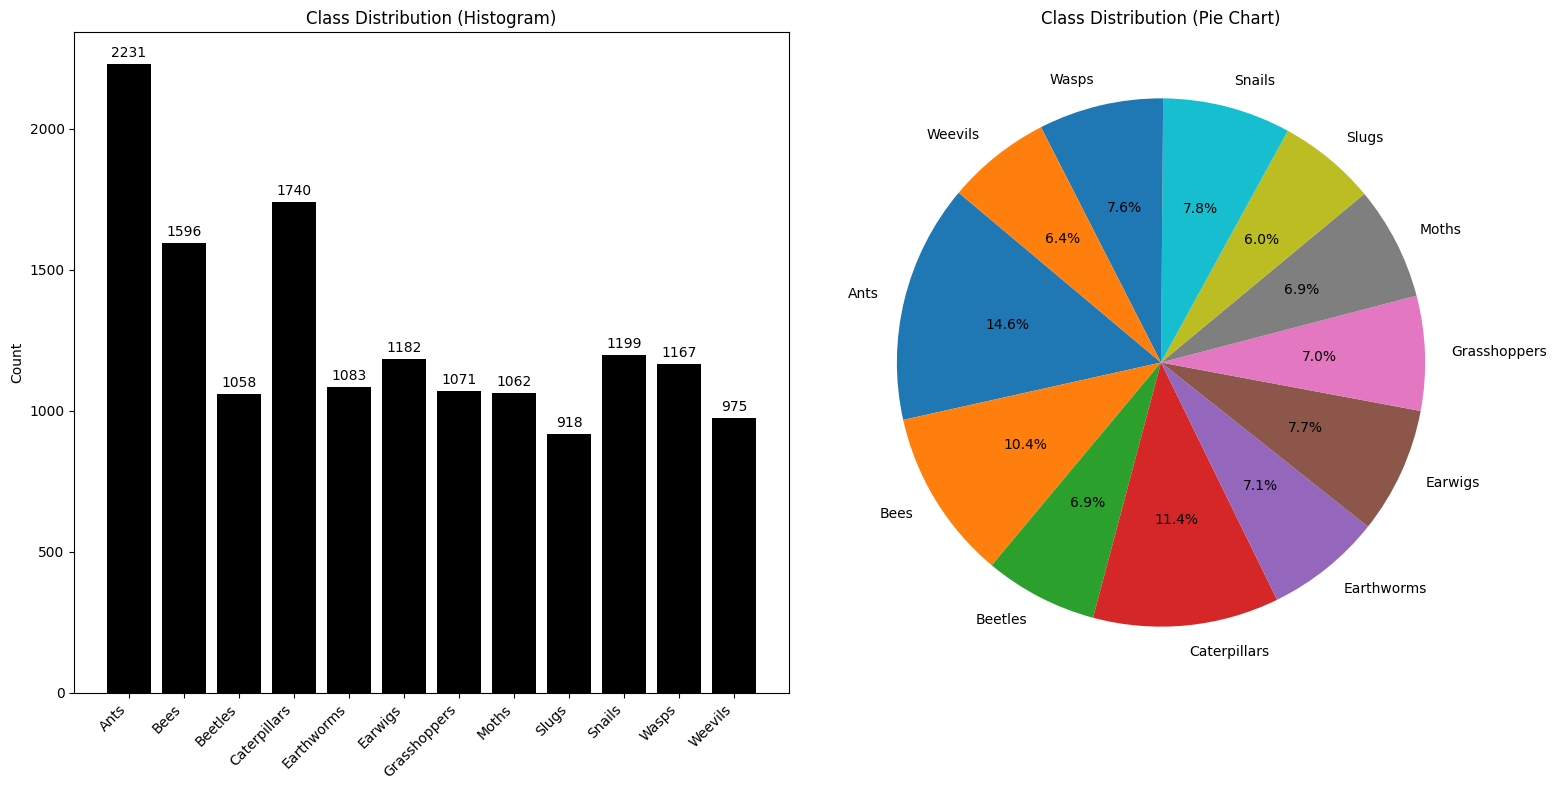

========= Test Set Distribution =========


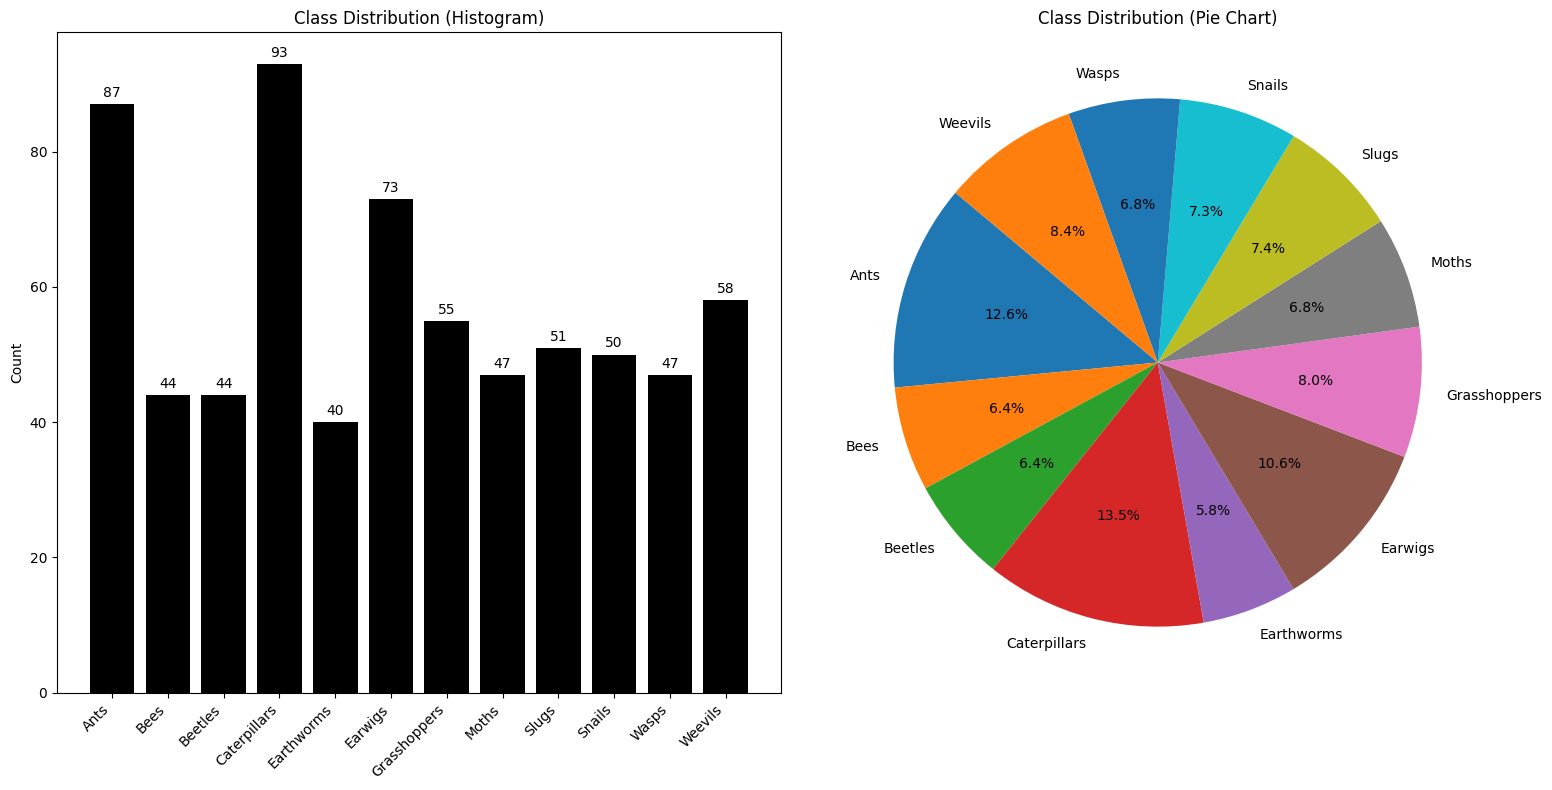

========= Validation Set Distribution =========


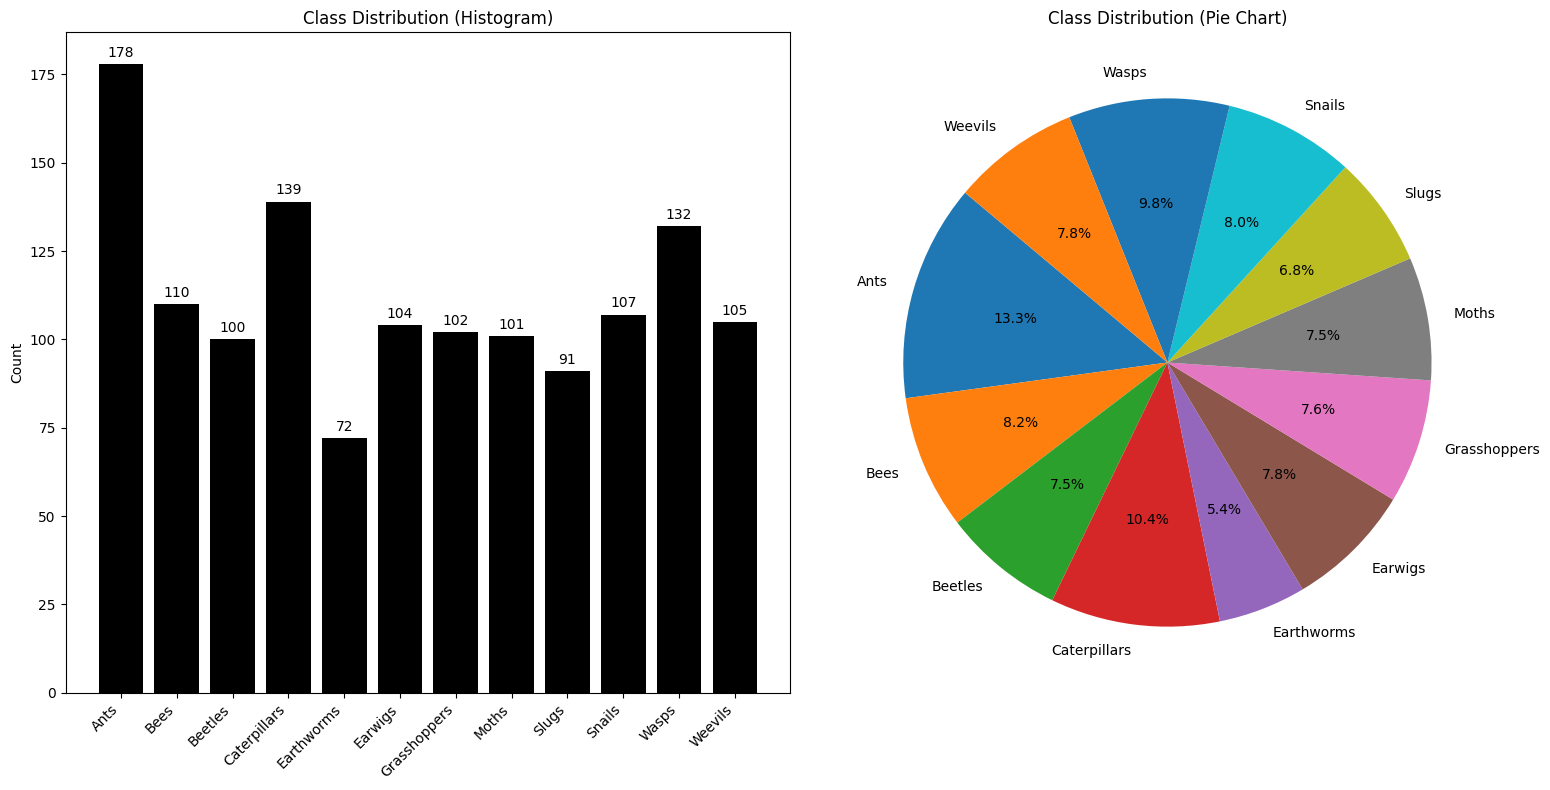

In [ ]:
import matplotlib.pyplot as plt

def analyze_distribution(path):
    class_counts = {i: 0 for i in range(len(class_names))}
    for file in path.glob("*.txt"):
        with open(file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
    total = sum(class_counts.values())
    names = [class_names[i] for i in class_counts.keys()]
    rates = [count / total * 100 for count in class_counts.values()]

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))

    bars = axs[0].bar(names, list(class_counts.values()), color='black')
    axs[0].bar_label(bars, padding=3)
    axs[0].set_xticks(range(len(names)))
    axs[0].set_xticklabels(names, rotation=45, ha='right')
    axs[0].set_ylabel("Count")
    axs[0].set_title("Class Distribution (Histogram)")

    axs[1].pie(rates, labels=names, autopct='%1.1f%%', startangle=140)
    axs[1].set_title("Class Distribution (Pie Chart)")

    plt.tight_layout()
    plt.show()

print("========= Training Set Distribution =========")
analyze_distribution(train_lab_path)
print("========= Test Set Distribution =========")
analyze_distribution(test_lab_path)
print("========= Validation Set Distribution =========")
analyze_distribution(valid_lab_path)


# 绘制目标框

In [ ]:
# def visualize_samples(images_path, labels_path, num_samples=6):
#     """Visualize sample images with bounding boxes and labels"""
#     image_files = list(images_path.glob('*.jpg'))[:num_samples]

#     fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#     axes = axes.flatten()

#     for idx, img_file in enumerate(image_files):
#         # Load image
#         img = cv2.imread(str(img_file))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         h, w = img.shape[:2]

#         # Load corresponding label
#         label_file = labels_path / (img_file.stem + '.txt')

#         if label_file.exists():
#             with open(label_file, 'r') as f:
#                 for line in f:
#                     parts = line.strip().split()
#                     class_id = int(parts[0])
#                     # YOLO format: class_id, center_x, center_y, width, height (normalized)
#                     cx, cy, bw, bh = map(float, parts[1:5])

#                     # Convert to pixel coordinates
#                     x1 = int((cx - bw/2) * w)
#                     y1 = int((cy - bh/2) * h)
#                     x2 = int((cx + bw/2) * w)
#                     y2 = int((cy + bh/2) * h)

#                     # Draw bounding box
#                     cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

#                     # Add label
#                     label_text = class_names[class_id]
#                     cv2.putText(img, label_text, (x1, y1-10),
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

#         axes[idx].imshow(img)
#         axes[idx].axis('off')
#         axes[idx].set_title(f'Sample {idx+1}')

#     plt.tight_layout()
#     plt.show()

# visualize_samples(train_images, train_labels, num_samples=6)


# 裁剪目标

In [ ]:
from tqdm import tqdm

def crop_img(images_path, lab_path, max_no=None):
    cropped_images = {}

    images = list(images_path.glob('*.jpg'))
    if max_no:
        images = images[:max_no]

    for img in tqdm(images, desc="Extracting features"):
        img_path = images_path / img
        lab = lab_path / (img.stem + '.txt')
        img = cv2.imread(str(img))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        if lab.exists():
            with open(lab, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])

                    x1 = max(0, int((cx - bw/2) * w))
                    y1 = max(0, int((cy - bh/2) * h))
                    x2 = min(w, int((cx + bw/2) * w))
                    y2 = min(h, int((cy + bh/2) * h))

                    cropped = img[y1:y2, x1:x2]

                    if cropped.size > 0:
                        if class_id not in cropped_images:
                            cropped_images[class_id] = []
                        cropped_images[class_id].append((str(img_path),cropped))
        else:
            print(f"Label file not found for image: {img.stem}")
    return cropped_images

print("Cropping training images...")
train_cropped = crop_img(train_img_path, train_lab_path)
print("\nCropping testing images...")
test_cropped = crop_img(test_img_path, test_lab_path)
print("\nCropping validation images...")
valid_cropped = crop_img(valid_img_path, valid_lab_path)

Cropping training images...


Extracting features: 100%|██████████| 11502/11502 [00:36<00:00, 314.99it/s]



Cropping testing images...


Extracting features: 100%|██████████| 546/546 [00:01<00:00, 307.70it/s]



Cropping validation images...


Extracting features: 100%|██████████| 1095/1095 [00:03<00:00, 307.25it/s]


# 方法1：传统机器学习的方法

**简介**: HOG(Histogram of Oriented Gradients) 做特征提取， 逻辑回归用于做分类器

**步骤**:
1. 目标检测: 直接用 ground-truth 边界框，即人家标注好的目标框，这样可以只关注分类结果而不必考虑目标检测效果
2. 特征提取: 用 HOG, 捕捉图像中局部的边缘和形状信息，来捕捉纹理和形状特征
3. 分类: 逻辑回归和随机森林进行对比

**备注**:
传统机器学习方法通常在正确定位目标之后进行分类，因此这儿用真实标注的框的数据作为输入，以保证分类的公平对比和准确性。整个流程相对简单，适合理解与基准测试，特别是在深度学习尚未盛行之前是经典方案。

In [ ]:
from skimage.feature import hog
from skimage import color
import numpy as np

# Parameters for HOG
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)
TARGET_SIZE = (128, 128)

def extract_HOG_features(img):
    img = cv2.resize(img, TARGET_SIZE)
    if len(img.shape) == 3:
        img = color.rgb2gray(img)
    else:
        img = img
    features = hog(img, orientations=ORIENTATIONS,
                   pixels_per_cell=PIXELS_PER_CELL,
                   cells_per_block=CELLS_PER_BLOCK,
                   visualize=False, feature_vector=True)
    return features

def apply_HOG(imgset):
    features = []
    labels = []
    for class_id in imgset.keys():
        for _, img in imgset[class_id]:
            features.append(extract_HOG_features(img))
            labels.append(class_id)
    return np.array(features), np.array(labels)

print("Extracting HOG features from training set...")
X_train, Y_train = apply_HOG(train_cropped)
print(f"Training samples: {len(X_train)}, Feature dimension: {X_train.shape[1]}")

print("\nExtracting HOG features from test set...")
X_test, Y_test = apply_HOG(test_cropped)
print(f"Test samples: {len(X_test)}, Feature dimension: {X_test.shape[1]}")

print("\nExtracting HOG features from validation set...")
X_val, Y_val = apply_HOG(valid_cropped)
print(f"Validation samples: {len(X_val)}, Feature dimension: {X_val.shape[1]}")


Extracting HOG features from training set...
Training samples: 15282, Feature dimension: 8100

Extracting HOG features from test set...
Test samples: 689, Feature dimension: 8100

Extracting HOG features from validation set...
Validation samples: 1341, Feature dimension: 8100


In [ ]:
import time
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,confusion_matrix
from sklearn.preprocessing import label_binarize
import seaborn as sns

def init_eval_index(dic):

    # macro average evaluation
    dic["MAC Precision"] = []
    dic["MAC Recall"] = []
    dic["MAC F1-Score"] = []
    dic["MAC AUC"] = []

    # weighted average evaluation
    dic["WTD Precision"] = []
    dic["WTD Recall"] = []
    dic["WTD F1-Score"] = []
    dic["WTD AUC"] = []

    # overall
    dic["Test Accuracy"] = []
    return dic


def eval_classifier(classifier,dic):

    test_start_time = time.time()
    pred = classifier.predict(X_test)
    pred_proba = classifier.predict_proba(X_test)
    test_time = time.time() - test_start_time
    Y_test_bin = label_binarize(Y_test, classes=range(len(class_names)))
    if Y_test_bin.shape[1] == 1:
        Y_test_bin = np.hstack((1 - Y_test_bin, Y_test_bin))

    accuracy = accuracy_score(Y_test, pred)
    dic["Test Accuracy"].append(f"{accuracy:.2%}")

    MAC_pre =  precision_score(Y_test, pred, average='macro', zero_division=0)
    MAC_rec = recall_score(Y_test, pred, average='macro', zero_division=0)
    MAC_f1 = f1_score(Y_test, pred, average='macro', zero_division=0)
    MAC_auc = roc_auc_score(Y_test_bin, pred_proba, average='macro', multi_class='ovr')

    dic["MAC Precision"].append(f"{MAC_pre:.2%}")
    dic["MAC Recall"].append(f"{MAC_rec:.2%}")
    dic["MAC F1-Score"].append(f"{MAC_f1:.2%}")
    dic["MAC AUC"].append(f"{MAC_auc:.2%}")

    WTD_pre =  precision_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_rec = recall_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_f1 = f1_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_auc = roc_auc_score(Y_test_bin, pred_proba, average='weighted', multi_class='ovr')

    dic["WTD Precision"].append(f"{WTD_pre:.2%}")
    dic["WTD Recall"].append(f"{WTD_rec:.2%}")
    dic["WTD F1-Score"].append(f"{WTD_f1:.2%}")
    dic["WTD AUC"].append(f"{WTD_auc:.2%}")

    cm = confusion_matrix(Y_test, pred)
    return pred,pred_proba,cm,dic

def show_results(dic):
    line = "Group          :"
    for i in range(len(list(dic.values())[0])):
        line += f"{i:^8}  "
    print(line)
    for _,para in enumerate(dic.keys()):
        line = f"{para:<15}:  "
        for data in dic[para]:
            line += f"{data:^10}"
        print(line)

def show_cm(cm):
    _, axes = plt.subplots(1, len(cm), figsize = (12*len(cm), 10))
    for i in range(len(cm)):
        sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names, ax=axes[i])
        axes[i].set_xlabel('Pred')
        axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.show()


## 逻辑回归训练
关于参数

**MULTI_CLASS:**:

(using multinomial as default)
1. `ovr(one-vs-rest):` 对K分类问题训练K个二分类器，每次将某一类别作为正类，其余类别作为负类。适合二分类或多分类问题，简单且计算效率较高。
2. `multinomial:` 直接对多分类问题进行建模，采用softmax函数，数学上更严谨，适合类别间关系复杂的多分类任务。但对计算资源要求更高。

**SOLVER:**
1. `liblinear:` 基于坐标轴下降法（coordinate descent）的优化算法，适合小型数据集和二分类问题，支持L1和L2正则化，但不支持多项式模型。
2. `lbfgs:` 拟牛顿法，适合中小型数据集和多分类问题，支持L2正则化，收敛速度较快，是默认选项。
3. `newton-cg:` 牛顿共轭梯度法，适合多分类问题，支持L2正则化，计算开销较大但精度较高。
4. `sag: ` 随机平均梯度下降法，适用于大规模数据集，收敛速度快，但仅支持L2正则化。
5. `saga:` 是SAG的一个扩展，支持L1、L2和弹性网络正则化，适合大规模数据和稀疏特征，同时支持多分类。

**C:**

表示正则化强度，越大，便允许模型更复杂，容易过拟合，反之容易欠拟合

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)



# parameters for Logistic Regression
LR_dict = {
    "Max Iter": [50, 50, 50],
    # the experiment has shown that it's enough to converge.
    "Solver": ['lbfgs', 'newton-cg', 'sag'],
    "C": [1.0, 1.0, 1.0],
}

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

def LR_train(max_iter, solver, c):
    start_time = time.time()

    classifier = LogisticRegression(
        max_iter = max_iter,
        solver = solver,
        C = c,
        random_state = RANDOM_STATE,
        n_jobs = -1,                  # Use all CPU cores
    )
    classifier.fit(X_train, Y_train)

    train_time = time.time() - start_time

    val_pred = classifier.predict(X_val)
    val_acc = accuracy_score(Y_val, val_pred)
    LR_dict["Val Acc"].append(f"{val_acc:.2%}")
    LR_dict["Train Time"].append(f"{train_time:.2f}s")
    return classifier

LR_dict["Train Time"] = []
LR_dict["Val Acc"] = []

LR_dict = init_eval_index(LR_dict)

LR_pred = []
LR_pred_prob = []
LR_cm = []
for i in range(len(list(LR_dict.values())[0])):
    LR_classifier = LR_train(LR_dict["Max Iter"][i],LR_dict["Solver"][i],LR_dict["C"][i])
    pred,pred_prob,cm,LR_dict = eval_classifier(LR_classifier,LR_dict)
    LR_pred.append(pred)
    LR_pred_prob.append(pred_prob)
    LR_cm.append(cm)


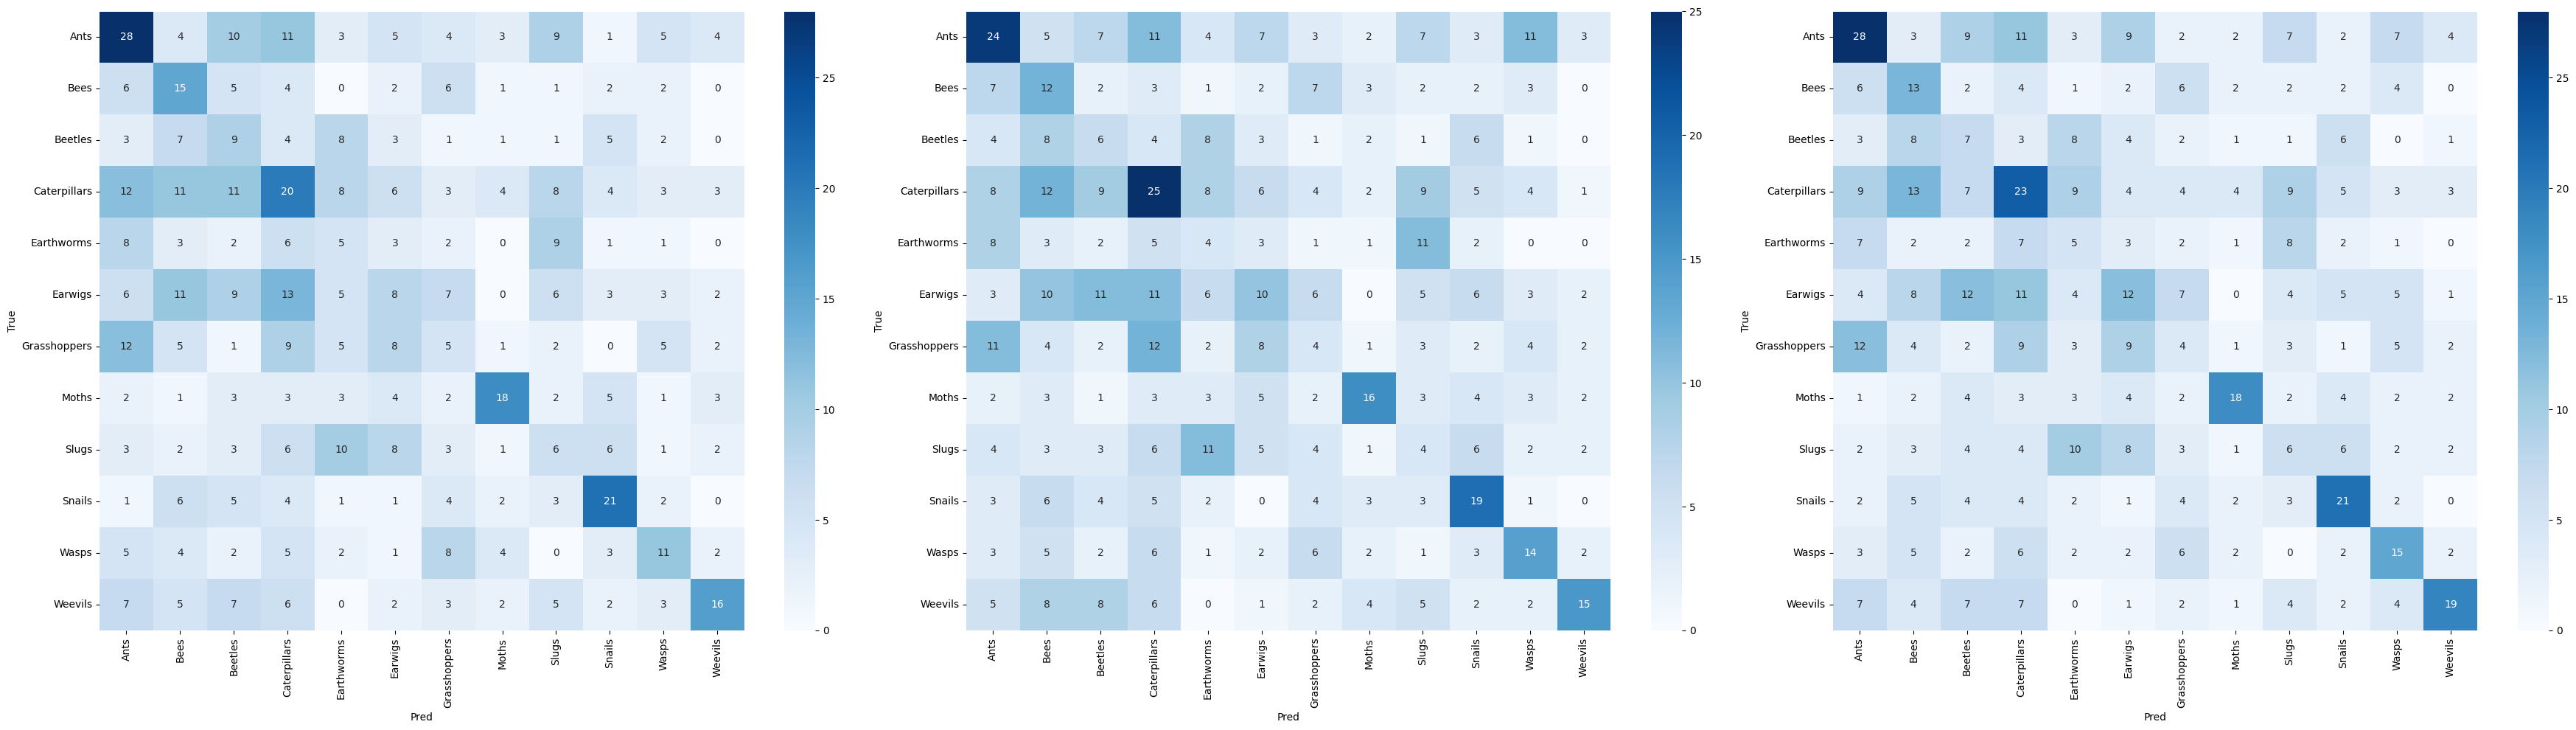

Group          :   0         1         2      
Max Iter       :      50        50        50    
Solver         :    lbfgs   newton-cg    sag    
C              :     1.0       1.0       1.0    
Train Time     :    16.33s   197.31s   147.34s  
Val Acc        :    23.34%    24.46%    24.91%  
MAC Precision  :    24.75%    23.36%    25.86%  
MAC Recall     :    23.65%    21.82%    24.61%  
MAC F1-Score   :    23.66%    21.94%    24.76%  
MAC AUC        :    70.47%    70.84%    71.56%  
WTD Precision  :    24.93%    24.18%    26.48%  
WTD Recall     :    23.51%    22.21%    24.82%  
WTD F1-Score   :    23.73%    22.58%    25.23%  
WTD AUC        :    69.98%    70.33%    71.12%  
Test Accuracy  :    23.51%    22.21%    24.82%  


In [ ]:
show_cm(LR_cm)
show_results(LR_dict)

验证集准确率只有23.79%（12类昆虫中随机猜测准确率大概8%），说明模型表现较差。常见可能原因及改进方向包括：

**可能原因:**
1. `特征表达不足:` HOG主要捕捉边缘和方向梯度信息，可能对复杂纹理和颜色信息捕捉有限，不够区分不同昆虫。

2. `模型能力有限:` 逻辑回归是线性分类器，对于复杂的非线性分类任务表现有限，12类多分类问题较难仅用线性决策边界区分。

3. `数据预处理或划分问题:` 归一化不当、数据集过小、类别严重不平衡等都可能影响效果。

4. `参数调优不足:` 正则化参数C、迭代次数等未调好，或者HOG提取参数如单元格大小、区块大小不合适。

**改进建议:**
1. `丰富特征:` 结合颜色直方图、纹理特征（如LBP），或使用深度学习自动特征提取（卷积神经网络）往往效果更好。

2. `更强模型:` 尝试随机森林、支持向量机，或深度学习模型如CNN等非线性模型。

3. `增加数据量和数据增强:` 扩充样本，使用旋转、镜像、变换等数据增强提升泛化能力。

4. `细调HOG参数:` 优化单元格大小、块大小、梯度方向数等，找到更适合昆虫图像的特征尺度。

5. `调参和交叉验证:` 细致调节模型参数和特征提取参数，采用交叉验证选最优组合。

6. `考虑滤除噪声及图像预处理:` 提高图像质量，有助提升特征的判别力。

综上，HOG+逻辑回归可作为起点，但较佳方案需结合更丰富特征和更复杂模型，或转深度学习路线.​

## 随机森林

## 随机森林训练
关于参数

**N_ESTIMATORS:**:

指定森林中决策树的数量。更多树通常能提高模型的性能和稳定性，但会增加训练和预测的计算成本。比如200棵树可以保证模型有较强的拟合能力和抗过拟合能力，但过多也会带来计算开销较大

**MAX_DEPTH:**

限制每棵决策树的最大深度，防止过拟合。深度越大，树越复杂，对训练数据拟合越细致，但也可能导致过拟合。设置30深度一般是一个适中值，可以适应多数任务

**MIN_SAMPLE_SPLIT:**

（内部节点再划分所需最小样本数）：控制一个节点继续拆分所需的最少样本数量。数值越大，约束越强，树越浅，防止过拟合。5表示节点至少有5个样本才继续分裂，否则停止划分

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# parameters for Random Forest
RF_dict = {
    "N Estimators": [200, 200, 200, 200, 200, 200],
    "Max Depth": [20, 25, 30, 20, 25, 30],
    "Min Samples Split": [5, 5, 5, 10, 10, 10]
}

def RF_train(N_estimators, max_depth, min_samples_split):
    start_time = time.time()
    classifier = RandomForestClassifier(
        n_estimators = N_estimators,
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        random_state = 10086,
        n_jobs = -1
    )
    classifier.fit(X_train, Y_train)

    train_time = time.time() - start_time
    val_pred = classifier.predict(X_val)
    val_acc = accuracy_score(Y_val, val_pred)
    RF_dict["Train Time"] = f"{train_time:.2f}s"
    RF_dict["Val Acc"] = f"{val_acc:.2%}"

RF_dict["Train Time"] = []
RF_dict["Val Acc"] = []

RF_dict = init_eval_index(LR_dict)

RF_pred = []
RF_pred_prob = []
RF_cm = []
print(RF_dict.keys())

for i in range(len(list(RF_dict.values())[0])):
    RF_classifier = RF_train(RF_dict["N Estimators"][i],RF_dict["Max Depth"][i],RF_dict["Min Samples Split"][i])
    pred,pred_prob,cm,RF_dict = eval_classifier(RF_classifier,RF_dict)
    RF_pred.append(pred)
    RF_pred_prob.append(pred_prob)
    RF_cm.append(cm)



dict_keys(['Max Iter', 'Solver', 'C', 'Train Time', 'Val Acc', 'MAC Precision', 'MAC Recall', 'MAC F1-Score', 'MAC AUC', 'WTD Precision', 'WTD Recall', 'WTD F1-Score', 'WTD AUC', 'Test Accuracy'])


KeyError: 'N Estimators'

In [ ]:
show_cm(RF_cm)
show_results(RF_dict)

# Method 2.1: Deep learning aproach (YOLOv11)
**Introduction**: Use YOLOv11l for Unified Object Detection and Multi-Class Pest.

YOLOv11 leverage deeper feature hierarchies and improved spatial representations, enabling more accurate recognition of small and fine-grained pest categories.

**Steps**:
1. Prepare the required data configuration for YOLO.
2. Train the YOLOv11 model.
3. Evaluate mAP and other metrics using the validation set.
4. Perform inference and visualization on the test set.
5. Perform XAI (Explainable AI) on YOLOv11

### Train the yolov11l model

In [ ]:
yolov11Model = YOLO("yolo11l.pt")

yolov11Model.train(
    data="data.yaml",
    epochs=100,
    imgsz=1536,
    batch=16,
    device=0,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,
    cos_lr=True,
    patience=50,
    seed=0,
    cache="ram",
    workers=4,
    project="/content/drive/MyDrive/YOLOv11_Results",
    name="AgroPest_yolov11l",
    )


### Evaluate the model

In [ ]:
yolobest = YOLO("/content/drive/MyDrive/YOLOv11_Results/AgroPest_yolov115/weights/best.pt")

ytest = yolobest.val(
    data="/content/dataset/data.yaml",
    imgsz=1536,
    batch=16,
    split='test',
    project="/content/drive/MyDrive/YOLOv11_Results/AgroPest_yolov115",
    name="AgroPest_y11_test",
    exist_ok=True,
)

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11m summary (fused): 125 layers, 20,039,284 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1561.1±462.8 MB/s, size: 51.7 KB)
val: Scanning /content/dataset/test/labels... 546 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 546/546 1.4Kit/s 0.4s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.5it/s 13.9s
                   all        546        689      0.769      0.676      0.722      0.313
                  Ants         54         87      0.882      0.686      0.757      0.324
                  Bees         40         44      0.903      0.886       0.89      0.382
               Beetles         41         44       0.75      0.568      0.739       0.37
          Caterpillars         46         93      0.768      0.392  

### Visualize the model on the test set

In [ ]:
def predict_on_test():
    yolobest = YOLO("/content/drive/MyDrive/YOLOv11_Results/AgroPest_yolov115/weights/best.pt")

    results = yolobest.predict(
        source="/content/dataset/test/images",
        imgsz=1536,
        conf=0.5,
        device=0,
        save=True,
        project="/content/drive/MyDrive/YOLOv11_Results/AgroPest_yolov115",
        name="AgroPest_y11_predict",
    )

### Perform XAI (Explainable AI) on YOLOv11

In [ ]:
!pip install -q ultralytics grad-cam ttach opencv-python
!git clone -q https://github.com/rigvedrs/YOLO-V8-CAM.git
%cd YOLO-V8-CAM


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/content/YOLO-V8-CAM/YOLO-V8-CAM/YOLO-V8-CAM


In [ ]:
import ultralytics
from ultralytics import YOLO

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [ ]:
plt.rcParams["figure.figsize"] = [8, 8]

In [ ]:
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

In [ ]:
model = YOLO('/content/drive/MyDrive/YOLOv11_Results/AgroPest_yolov115/weights/best.pt')
model = model.cpu()

In [ ]:
img = cv2.imread('/content/dataset/test/images/ants-241-_jpg.rf.e3ae012bda12b32d5a46f6b5d7c118f6.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [ ]:
target_layers =[model.model.model[-3]]


0: 1280x1280 1 Ants, 6213.9ms
Speed: 30.1ms preprocess, 6213.9ms inference, 2.1ms postprocess per image at shape (1, 3, 1280, 1280)


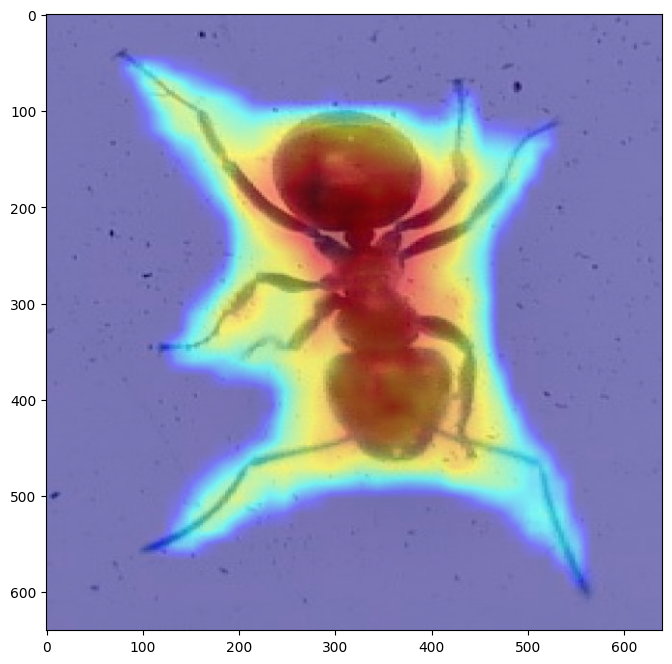

In [ ]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

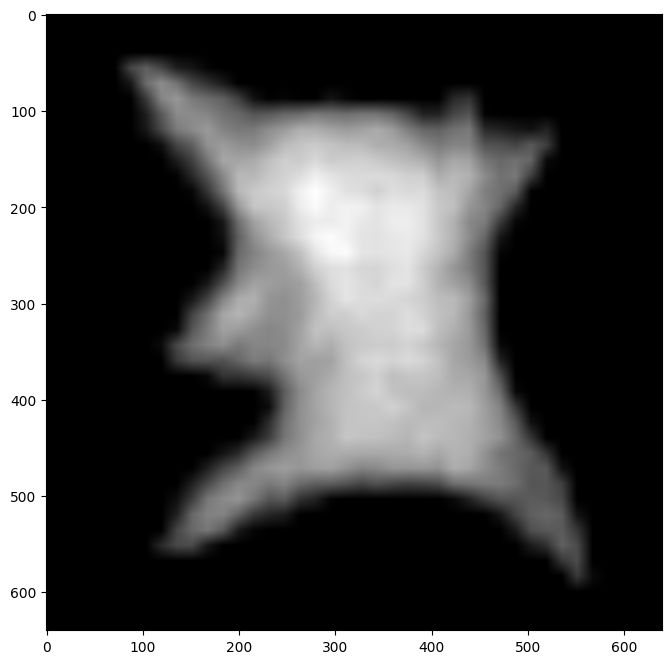

In [ ]:
import matplotlib.pyplot as plt
g_scale = np.stack([grayscale_cam] * 3, axis=2)
plt.imshow(g_scale)

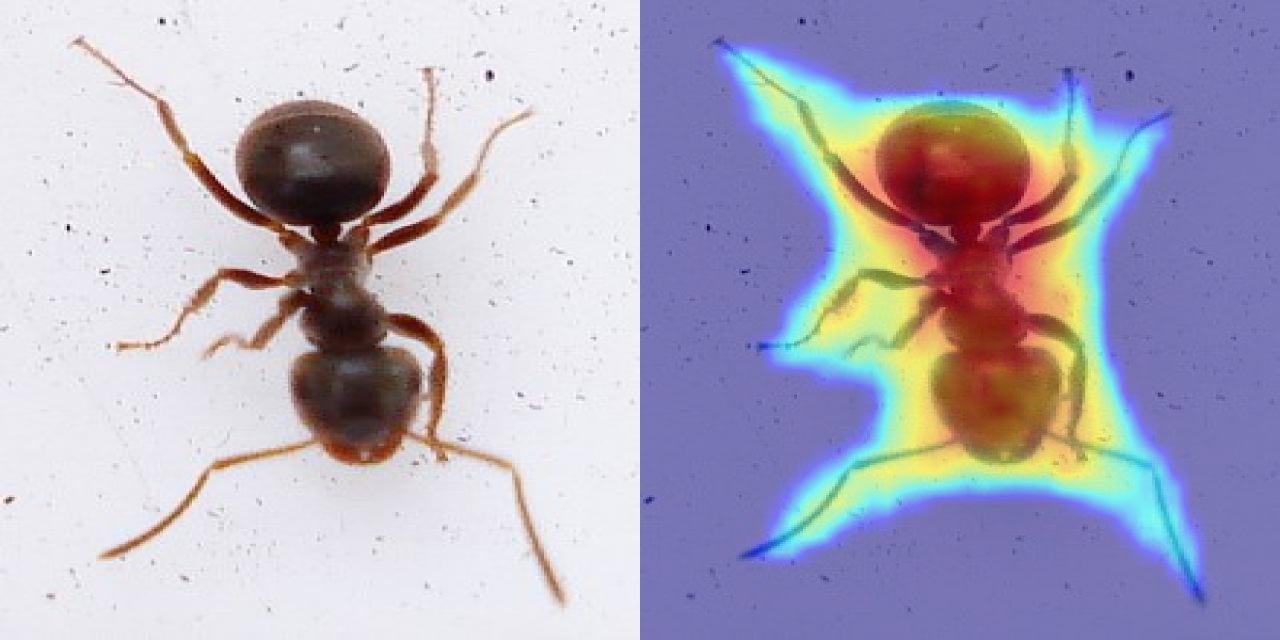

In [ ]:
im = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
Image.fromarray(np.hstack((im, cam_image)))

# Method 2.2: Deep learning aproach (RT-DETR)
**Introduction**: RT-DETR is an efficient, real-time variant of the original DETR architecture.

It preserves DETR’s end-to-end object detection pipeline while introducing several improvements that significantly accelerate training and inference.  This makes RT-DETR suitable for tasks involving small objects and complex backgrounds, such as insect detection in the AgroPest dataset.

**Characteristics**:
1. End-to-End Detection
2. Strong Global Context Modeling
3. Multi-Scale Feature Enhancement
4. Improved Speed Compared to DETR

### Train the rtdetr model

In [ ]:
rtdetr_model = RTDETR("rtdetr-l.pt")

rtdetr_model.train(
    data="/content/dataset/data.yaml",
    epochs=100,
    imgsz=1280,
    batch=8,
    workers=4,
    patience=30,
    cos_lr=True,
    project="/content/drive/MyDrive/rtdetr_Results",
    name="rtdetr_train",
)

### Evaluate the model

In [ ]:
rtdetrBestModel = RTDETR("/content/drive/MyDrive/rtdetr_Results/rtdetr_train3/weights/best.pt")

metrics = rtdetrBestModel.val(
    data="/content/dataset/data.yaml",
    imgsz=1280,
    split="val",
    batch=8,
    project="/content/drive/MyDrive/rtdetr_Results/rtdetr_train3",
    name="rtdetr_val",
)

print(f"mAP@50:     {metrics.box.map50:.4f}")
print(f"mAP@50-95:  {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")


Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
rt-detr-l summary: 302 layers, 32,008,400 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 946.6±413.8 MB/s, size: 28.0 KB)
val: Scanning /content/dataset/valid/labels... 1095 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 1.5Kit/s 0.7s
val: New cache created: /content/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 5.9it/s 23.2s
                   all       1095       1341      0.892      0.742      0.777      0.473
                  Ants         96        178      0.811      0.601      0.675      0.274
                  Bees         99        110       0.94      0.809      0.847      0.391
               Beetles         89        100      0.822      0.692      0.671      0.349
          Caterpillars         77        139       0.86      0.486 

### Visualize the model on the test set

In [ ]:
rtdetrBestModel = RTDETR("/content/drive/MyDrive/rtdetr_Results/rtdetr_train3/weights/best.pt")

rtdetrBestModel.predict(
    source="/content/dataset/test/images",
    imgsz=1280,
    conf=0.25,
    iou=0.5,
    device=0,
    save=True,
    project="/content/drive/MyDrive/rtdetr_Results/rtdetr_train3",
    name="rtdetr_predict",
)


### Perform XAI (Explainable AI) on RT-DETR

In [ ]:
weights_path = "/content/drive/MyDrive/rtdetr_Results/rtdetr_train3/weights/best.pt"
img_path = "/content/dataset/test/images/ants-241-_jpg.rf.e3ae012bda12b32d5a46f6b5d7c118f6.jpg"

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [ ]:
rtdetr_task = RTDETR(weights_path)

det_model = rtdetr_task.model.to(device)
det_model.eval()

In [ ]:
class RTDETRForCAM(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        while isinstance(out, (list, tuple)):
            out = out[0]
        return out

cam_model = RTDETRForCAM(det_model)

In [ ]:
img_bgr = cv2.imread(img_path)

img_bgr = cv2.resize(img_bgr, (640, 640))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_float = img_rgb.astype(np.float32) / 255.0

input_tensor = (
    torch.from_numpy(img_float)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .to(device)
)

print("input_tensor.shape:", input_tensor.shape)

input_tensor.shape: torch.Size([1, 3, 640, 640])


In [ ]:
target_layers = [det_model.model[-2]]

In [ ]:
cam = EigenCAM(
    model=cam_model,
    target_layers=target_layers,
)

grayscale_cam.shape: (640, 640)
EigenCAM save to： /content/drive/MyDrive/rtdetr_Results/eigencam_rtdetr_ants241.png


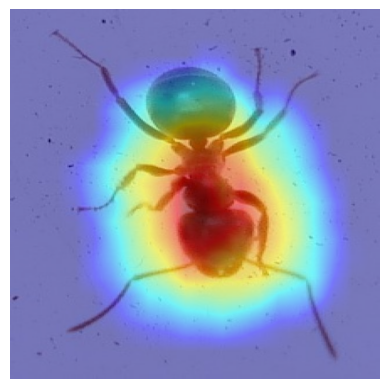

In [ ]:
grayscale_cam = cam(input_tensor=input_tensor)[0]
print("grayscale_cam.shape:", grayscale_cam.shape)

cam_image = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
cam_image_bgr = cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR)

save_path = "/content/drive/MyDrive/rtdetr_Results/eigencam_rtdetr_ants241.png"
cv2.imwrite(save_path, cam_image_bgr)
print("EigenCAM save to：", save_path)

from matplotlib import pyplot as plt
plt.imshow(cam_image)
plt.axis("off")
plt.show()